In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import ticker

%matplotlib inline

## Scaling

### IsoFLOP profiles

For every fixed compute budget, fit

$$
\log_{10} L = a\left(\log_{10} N\right)^2 + b\log_{10}N + c,
$$

where $N$ is model size and $L$ is either validation or training loss. The vertex gives the compute-optimal model size. Its paired training-token count is obtained by log-log interpolation within the same fixed-compute slice. If a vertex falls outside the tested model-size range, the reported optimum is clipped to the nearest tested boundary and flagged in the summary.

The custom ViT uses $256\times256$ images and $16\times16$ patches with no class token, giving $(256/16)^2=256$ tokens per image. For the IsoFLOP runs, each iteration contains 512 images, so one iteration is 131,072 tokens. One pass through the training data (85,693 iterations) is 11,231,952,896 tokens.

This follows the IsoFLOP-profile method in Figure 3 of [Hoffmann et al. (2022)](https://arxiv.org/abs/2203.15556).

In [2]:
# Find the package from the repository root or notebooks/manuscript/.
import sys

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents)
            if (path / "pyproject.toml").is_file() and (path / "ptycho_fm").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ptycho_fm.isoflop import (
    fit_budget as shared_fit_budget,
)
from ptycho_fm.isoflop import (
    format_flops,
    historical_token_compute,
    validate_data,
)
from ptycho_fm.utils.flops import PtychoFMFlopsCalculator

PAPER_DIR = Path(os.environ.get("PTYCHO_FM_PAPER_DIR", ROOT / "workspace" / "paper"))
PAPER_DIR.mkdir(parents=True, exist_ok=True)
POINTS_CSV = PAPER_DIR / "isoflop_points.csv"
METRICS = {
    "validation": ("val_loss", "Validation loss"),
    "training": ("train_loss", "Training loss"),
}
REQUIRED_COLUMNS = {
    "target_flops",
    "params_m",
    "iter",
    "train_loss",
    "val_loss",
}

IMAGE_SIZE = 256
PATCH_SIZE = 16
TOKENS_PER_IMAGE = (IMAGE_SIZE // PATCH_SIZE) ** 2
IMAGES_PER_ITERATION = 512
TOKENS_PER_ITERATION = TOKENS_PER_IMAGE * IMAGES_PER_ITERATION
ONE_EPOCH_ITERATIONS = 85_693
ONE_EPOCH_TOKENS = ONE_EPOCH_ITERATIONS * TOKENS_PER_ITERATION
FIGURE_SIZE = (6.5, 2.5)
FIGURE_SCALE = 0.5
MARKER_AREA_SCALE = FIGURE_SCALE**2

# Processed patterns, token totals, and completed epochs for Figure 2 pre-training.
CHECKPOINT_PRETRAINING = {
    "43M": {
        "processed_patterns_per_epoch": int(0.975 * 54_000_000),
        "epochs": 20,
        "total_tokens": int(0.975 * 54_000_000) * TOKENS_PER_IMAGE * 20,
    },
    "200M": {
        "processed_patterns_per_epoch": 20_000_000,
        "epochs": 51,
        "total_tokens": 5_120_000_000 * 51,
    },
}

def make_model_config(embed_dim, depth, num_heads, base_channels):
    return {
        "encoder_type": "custom",
        "decoder_type": "standard",
        "encoder": {
            "embed_dim": embed_dim,
            "depth": depth,
            "num_heads": num_heads,
        },
        "decoder": {
            "base_channels": base_channels,
            "latent_dim": None,
        },
    }


model_configs = {
    "43M": make_model_config(512, 12, 8, 64),
    "200M": make_model_config(896, 20, 14, 64),
}

# User-confirmed sampling metadata. Pretraining batch size remains approximate;
# historical compute below uses documented tokens, not reconstructed iterations.
HISTORICAL_RUN_METADATA = {
    '43M': {'pretrain_ranks': 1024, 'pretrain_batch_per_rank_likely': 32,
            'pretrain_sharding': 'dynamic'},
    '200M': {'pretrain_ranks': 1024, 'pretrain_batch_per_rank_likely': 32,
             'pretrain_sharding': 'static'},
}
FINETUNE_BATCH_PER_RANK = 128
FINETUNE_DROP_LAST_ASSUMED = False

# Figure 2 checkpoints are shown on scaling plots but never passed to a fit.
EXCLUDED_SCALING_POINTS = pd.DataFrame(
    [
        {
            "model": "43M",
            "training_flops": historical_token_compute(model_configs["43M"],
                CHECKPOINT_PRETRAINING["43M"]["total_tokens"]),
            "params_m": PtychoFMFlopsCalculator(model_configs["43M"], batch_size=1).param_count(),
            "tokens": CHECKPOINT_PRETRAINING["43M"]["total_tokens"],
            "marker": "s",
        },
        {
            "model": "200M",
            "training_flops": historical_token_compute(model_configs["200M"],
                CHECKPOINT_PRETRAINING["200M"]["total_tokens"]),
            "params_m": PtychoFMFlopsCalculator(model_configs["200M"], batch_size=1).param_count(),
            "tokens": CHECKPOINT_PRETRAINING["200M"]["total_tokens"],
            "marker": "D",
        },
    ]
)

points = pd.read_csv(POINTS_CSV)
validate_data(points)
if 'tokens_seen' in points and points['tokens_seen'].notna().all():
    points['tokens'] = points['tokens_seen']
else:
    if 'accounting_version' in points and (points['accounting_version'] == 'ptycho_fm_v1').any():
        raise ValueError('Current run records must supply tokens_seen')
    # Historical isoFLOP sweep used 512 images/iteration; these are not the
    # Figure 2 pretraining or fine-tuning batches documented above.
    points['tokens'] = points['iter'] * TOKENS_PER_ITERATION








def fit_budget(group, loss_column):
    result = shared_fit_budget(group, loss_column, length_column='tokens')
    result['token_coefficients'] = result.pop('iteration_coefficients')
    result['token_fit_r2_log_loss'] = result.pop('iteration_fit_r2_log_loss')
    result['optimum_tokens'] = result.pop('optimum_length')
    return result


print(f"Loaded {len(points)} points from {POINTS_CSV}")
print(f"Patch tokens per image: {TOKENS_PER_IMAGE:,}")
print(f"Tokens per iteration: {TOKENS_PER_ITERATION:,}")
print(f"One epoch: {ONE_EPOCH_TOKENS:,} tokens")
points.groupby("target_flops").size().rename("points")

Loaded 60 points from /home/aileenluo/ptycho-fm/workspace/paper/isoflop_points.csv
Patch tokens per image: 256
Tokens per iteration: 131,072
One epoch: 11,231,952,896 tokens


target_flops
6.000000e+17    13
1.000000e+18    13
3.000000e+18    12
6.000000e+18    11
1.000000e+19    11
Name: points, dtype: int64

In [3]:
def add_epoch_marker(axis, orientation="vertical"):
    """Mark one pass through the training data on a token axis."""
    marker_style = {"color": "0.72", "linestyle": "--", "linewidth": 1.4 * FIGURE_SCALE, "zorder": 0}
    if orientation == "vertical":
        axis.axvline(ONE_EPOCH_TOKENS, **marker_style)
        axis.annotate(
            "1 epoch",
            xy=(ONE_EPOCH_TOKENS, 0.98),
            xycoords=("data", "axes fraction"),
            xytext=(4, 0),
            textcoords="offset points",
            rotation=90,
            va="top",
            ha="left",
            color="0.45",
            fontsize=11 * FIGURE_SCALE,
        )
    elif orientation == "horizontal":
        axis.axhline(ONE_EPOCH_TOKENS, **marker_style)
        axis.annotate(
            "1 epoch",
            xy=(0.98, ONE_EPOCH_TOKENS),
            xycoords=("axes fraction", "data"),
            xytext=(0, 4),
            textcoords="offset points",
            va="bottom",
            ha="right",
            color="0.45",
            fontsize=11 * FIGURE_SCALE,
        )
    else:
        raise ValueError(f"Unknown marker orientation: {orientation}")


def plot_isoflop_metric(
    data,
    metric_name,
    loss_column,
    y_label,
    output_path,
    dpi=300,
):
    """Plot model-size and training-token views for one loss metric."""
    data = data.dropna(subset=[loss_column])
    budgets = np.sort(data["target_flops"].unique())
    palette = sns.color_palette("mako_r", n_colors=len(budgets))
    summaries = []

    style = {
        "font.size": 13 * FIGURE_SCALE,
        "axes.labelsize": 18 * FIGURE_SCALE,
        "xtick.labelsize": 14 * FIGURE_SCALE,
        "ytick.labelsize": 14 * FIGURE_SCALE,
        "legend.fontsize": 13 * FIGURE_SCALE,
        "legend.title_fontsize": 14 * FIGURE_SCALE,
        "axes.linewidth": 1.6 * FIGURE_SCALE,
    }
    with plt.rc_context(style):
        figure, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE, sharey=True)

        for budget, color in zip(budgets, palette, strict=True):
            group = data[data["target_flops"] == budget].sort_values("params_m")
            fit = fit_budget(group, loss_column)
            summaries.append({"metric": metric_name, **fit})

            params = group["params_m"].to_numpy(dtype=float)
            tokens = group["tokens"].to_numpy(dtype=float)
            losses = group[loss_column].to_numpy(dtype=float)

            if fit['model_coefficients'] is None:
                axes[0].scatter(params, losses, color=color, label=format_flops(budget))
                axes[1].scatter(tokens, losses, color=color)
                continue
            model_grid = np.geomspace(params.min(), params.max(), 300)
            token_grid = np.geomspace(tokens.min(), tokens.max(), 300)
            model_curve = 10.0 ** np.polyval(
                fit["model_coefficients"], np.log10(model_grid)
            )
            token_curve = 10.0 ** np.polyval(
                fit["token_coefficients"], np.log10(token_grid)
            )

            axes[0].plot(
                model_grid,
                model_curve,
                color=color,
                linewidth=2.2 * FIGURE_SCALE,
                label=format_flops(budget),
            )
            axes[0].scatter(params, losses, color=color, s=58 * MARKER_AREA_SCALE, zorder=3)
            axes[1].plot(token_grid, token_curve, color=color, linewidth=2.2 * FIGURE_SCALE)
            axes[1].scatter(tokens, losses, color=color, s=58 * MARKER_AREA_SCALE, zorder=3)


        axes[0].set_xscale("log")
        axes[1].set_xscale("log")
        axes[0].set_yscale("log")
        axes[0].yaxis.set_major_locator(ticker.LogLocator(base=10, subs=(1.0,)))
        axes[0].yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda value, _: f"{value:g}")
        )
        axes[0].yaxis.set_minor_locator(
            ticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1)
        )
        axes[0].yaxis.set_minor_formatter(ticker.NullFormatter())
        axes[0].set_xlabel("Model size (M)")
        axes[1].set_xlabel("Training tokens")
        axes[0].set_ylabel(y_label)
        axes[0].legend(title="FLOPs", loc="upper left", frameon=True)
        add_epoch_marker(axes[1], orientation="vertical")

        for axis in axes:
            axis.tick_params(which="major", direction="in", width=1.5 * FIGURE_SCALE, length=6 * FIGURE_SCALE)
            axis.tick_params(which="minor", direction="in", width=1.1 * FIGURE_SCALE, length=3 * FIGURE_SCALE)
            axis.margins(x=0.05)

        figure.tight_layout(w_pad=2.0)
        figure.savefig(output_path, dpi=dpi, transparent=True)
        plt.show()

    summary = pd.DataFrame(summaries)
    return summary.drop(columns=["model_coefficients", "token_coefficients"])

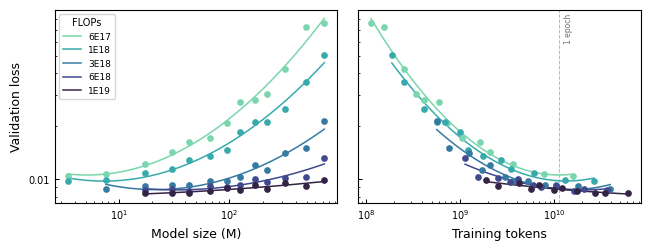

Wrote /home/aileenluo/ptycho-fm/workspace/paper/isoflop_validation.svg


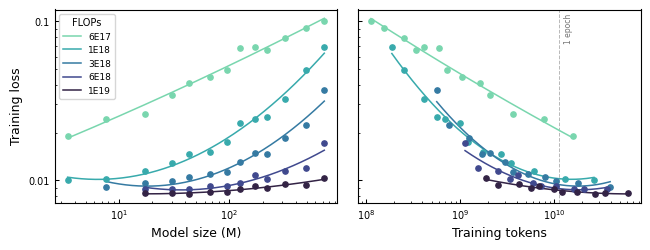

Wrote /home/aileenluo/ptycho-fm/workspace/paper/isoflop_training.svg
Wrote /home/aileenluo/ptycho-fm/workspace/paper/isoflop_optima.csv


,metric,target_flops,optimum_params_m,optimum_tokens,fitted_min_loss,vertex_in_observed_range,model_fit_r2_log_loss
0,validation,6e+17,5.169,"11,187,748,773",0.01057889,True,0.9841
1,validation,1e+18,7.369,"13,646,030,590",0.00977366,True,0.9848
2,validation,3e+18,21.556,"14,549,583,967",0.00875183,True,0.9484
3,validation,6e+18,33.052,"19,613,493,798",0.00872073,True,0.8628
4,validation,1e+19,17.094,"60,796,436,480",0.00827650,False,0.8381
5,training,6e+17,3.444,"15,991,963,648",0.01843590,False,0.9798
6,training,1e+18,6.436,"15,373,574,965",0.01014851,True,0.9865
7,training,3e+18,18.143,"17,210,341,316",0.00920663,True,0.9623
8,training,6e+18,36.953,"18,092,057,551",0.00871489,True,0.9115
9,training,1e+19,17.094,"60,796,436,480",0.00823155,False,0.9239


In [4]:
summaries = []
for metric_name, (loss_column, y_label) in METRICS.items():
    output_path = PAPER_DIR / f"isoflop_{metric_name}.svg"
    summaries.append(
        plot_isoflop_metric(
            points,
            metric_name,
            loss_column,
            y_label,
            output_path,
            
        )
    )
    print(f"Wrote {output_path}")

optima = pd.concat(summaries, ignore_index=True)
optima_path = PAPER_DIR / "isoflop_optima.csv"
optima.to_csv(optima_path, index=False)
print(f"Wrote {optima_path}")

optima[
    [
        "metric",
        "target_flops",
        "optimum_params_m",
        "optimum_tokens",
        "fitted_min_loss",
        "vertex_in_observed_range",
        "model_fit_r2_log_loss",
    ]
].style.format(
    {
        "target_flops": "{:.0e}",
        "optimum_params_m": "{:.3f}",
        "optimum_tokens": "{:,.0f}",
        "fitted_min_loss": "{:.8f}",
        "model_fit_r2_log_loss": "{:.4f}",
    }
)

### Compute-optimal scaling within the measured budgets

Fit power laws to the interior IsoFLOP vertices,

$$
Y_{\mathrm{opt}} = A\left(\frac{C}{10^{18}}\right)^b,
$$

for optimal model size and optimal training tokens. Training- and validation-loss results are kept in separate figures because the training-loss optima are less reliable. The fitted lines are shown only across the FLOP range measured by the scaling experiments; no larger-compute projection is made.

Filled points are interior parabola vertices used for the power-law fits. Open points are optima clipped to the edge of the tested model-size range; they are displayed but excluded from the scaling fits. A hollow square and hollow diamond show the 43M and 200M Figure 2 checkpoints, respectively, using the fit color for their outlines; they are reference points only and are also excluded from fitting. The light-purple dashed lines show the Chinchilla equal-scaling exponent ($b=0.5$), normalized to each empirical fit at $10^{18}$ FLOPs so that the comparison isolates the slope rather than transferring a language-model-specific intercept, and span the full displayed FLOP range. The one-epoch token count is vertical when tokens are on the x-axis in the IsoFLOP profiles above, and horizontal when tokens are on the y-axis in the scaling figures below.

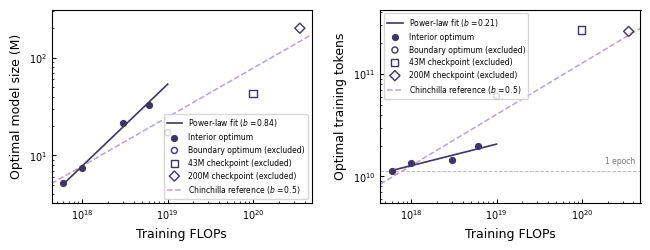

Wrote /home/aileenluo/ptycho-fm/workspace/paper/isoflop_validation_optimal_scaling.svg


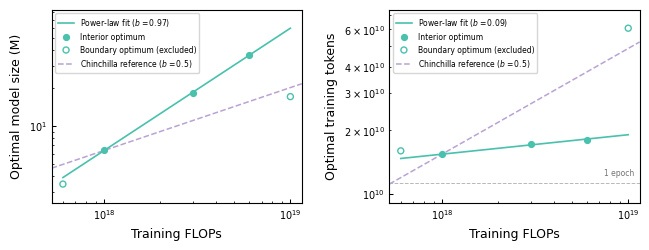

Wrote /home/aileenluo/ptycho-fm/workspace/paper/isoflop_training_optimal_scaling.svg


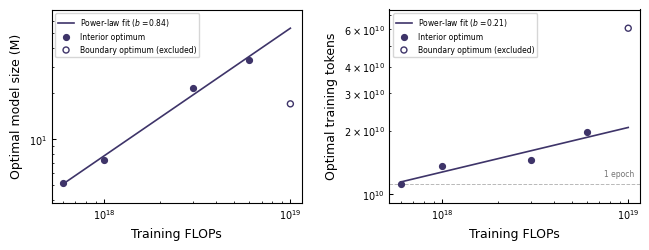

Wrote /home/aileenluo/ptycho-fm/workspace/paper/isoflop_validation_optimal_scaling_no_references.svg
Wrote /home/aileenluo/ptycho-fm/workspace/paper/isoflop_scaling_fits.csv


,metric,quantity,n_fit_points,value_at_1e18_flops,exponent,r2_log_log
0,validation,optimum_params_m,4,7.803,0.8365,0.9930
1,validation,optimum_tokens,4,1.275e+10,0.2103,0.8898
2,training,optimum_params_m,3,6.378,0.9726,0.9995
3,training,optimum_tokens,3,1.542e+10,0.0920,0.9920


In [5]:
COMPUTE_REFERENCE = 1e18
CHINCHILLA_EXPONENT = 0.5
CHINCHILLA_COLOR = "#b9a3d3"
SCALING_QUANTITIES = {
    "optimum_params_m": "Optimal model size (M)",
    "optimum_tokens": "Optimal training tokens",
}


def fit_power_law(compute, values, reference=COMPUTE_REFERENCE):
    """Fit values = value_at_reference * (compute / reference)**exponent."""
    if len(compute) < 2:
        raise ValueError('At least two interior optima are required for a scaling fit')
    log_compute = np.log10(np.asarray(compute, dtype=float) / reference)
    log_values = np.log10(np.asarray(values, dtype=float))
    exponent, log_value_at_reference = np.polyfit(log_compute, log_values, deg=1)
    predicted = exponent * log_compute + log_value_at_reference
    residual_sum = np.square(log_values - predicted).sum()
    total_sum = np.square(log_values - log_values.mean()).sum()
    r_squared = 1.0 - residual_sum / total_sum if total_sum > 0 else 1.0
    return {
        "value_at_1e18_flops": 10.0**log_value_at_reference,
        "exponent": float(exponent),
        "r2_log_log": float(r_squared),
    }


def plot_metric_scaling(
    metric_name,
    color,
    excluded_points=None,
    include_chinchilla=True,
    filename_suffix="",
    dpi=300,
):
    """Plot measured model-size and token optima for one loss metric."""
    metric_optima = optima[optima["metric"] == metric_name].sort_values(
        "target_flops"
    )
    interior = metric_optima[metric_optima["vertex_in_observed_range"]]
    boundary = metric_optima[~metric_optima["vertex_in_observed_range"]]
    metric_rows = []

    style = {
        "font.size": 13 * FIGURE_SCALE,
        "axes.labelsize": 18 * FIGURE_SCALE,
        "xtick.labelsize": 14 * FIGURE_SCALE,
        "ytick.labelsize": 14 * FIGURE_SCALE,
        "legend.fontsize": 11 * FIGURE_SCALE,
        "legend.title_fontsize": 12 * FIGURE_SCALE,
        "axes.linewidth": 1.6 * FIGURE_SCALE,
    }
    with plt.rc_context(style):
        figure, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

        for axis, (quantity, y_label) in zip(
            axes, SCALING_QUANTITIES.items(), strict=True
        ):
            fit = fit_power_law(interior["target_flops"], interior[quantity])
            metric_rows.append(
                {
                    "metric": metric_name,
                    "quantity": quantity,
                    "n_fit_points": len(interior),
                    **fit,
                }
            )

            compute_grid = np.geomspace(
                metric_optima["target_flops"].min(),
                metric_optima["target_flops"].max(),
                300,
            )
            fitted_values = fit["value_at_1e18_flops"] * (
                compute_grid / COMPUTE_REFERENCE
            ) ** fit["exponent"]

            axis.plot(
                compute_grid,
                fitted_values,
                color=color,
                linewidth=2.4 * FIGURE_SCALE,
                label=f"Power-law fit ($b={fit['exponent']:.2f}$)",
            )
            axis.scatter(
                interior["target_flops"],
                interior[quantity],
                color=color,
                s=70 * MARKER_AREA_SCALE,
                zorder=3,
                label="Interior optimum",
            )
            if not boundary.empty:
                axis.scatter(
                    boundary["target_flops"],
                    boundary[quantity],
                    facecolors="none",
                    edgecolors=[color],
                    linewidths=2.0 * FIGURE_SCALE,
                    s=75 * MARKER_AREA_SCALE,
                    zorder=3,
                    label="Boundary optimum (excluded)",
                )

            if excluded_points is not None:
                point_value_column = (
                    "params_m" if quantity == "optimum_params_m" else "tokens"
                )
                for point in excluded_points.itertuples(index=False):
                    axis.scatter(
                        point.training_flops,
                        getattr(point, point_value_column),
                        marker=point.marker,
                        s=105 * MARKER_AREA_SCALE,
                        facecolors="none",
                        edgecolors=[color],
                        linewidths=2.0 * FIGURE_SCALE,
                        zorder=5,
                        label=f"{point.model} checkpoint (excluded)",
                    )

            axis.set_xscale("log")
            axis.set_yscale("log")
            axis.set_xlabel("Training FLOPs")
            axis.set_ylabel(y_label)
            axis.tick_params(which="major", direction="in", width=1.5 * FIGURE_SCALE, length=6 * FIGURE_SCALE)
            axis.tick_params(which="minor", direction="in", width=1.1 * FIGURE_SCALE, length=3 * FIGURE_SCALE)
            axis.margins(x=0.05, y=0.12)
            if include_chinchilla:
                displayed_flop_range = axis.get_xlim()
                reference_compute_grid = np.geomspace(
                    *displayed_flop_range, 300
                )
                chinchilla_values = fit["value_at_1e18_flops"] * (
                    reference_compute_grid / COMPUTE_REFERENCE
                ) ** CHINCHILLA_EXPONENT
                axis.plot(
                    reference_compute_grid,
                    chinchilla_values,
                    color=CHINCHILLA_COLOR,
                    linestyle="--",
                    linewidth=2.2 * FIGURE_SCALE,
                    zorder=1,
                    label="Chinchilla reference ($b=0.5$)",
                )
                axis.set_xlim(displayed_flop_range)
            axis.legend(loc="best", frameon=True)

        add_epoch_marker(axes[1], orientation="horizontal")
        figure.tight_layout(w_pad=2.5)
        figure_path = (
            PAPER_DIR
            / f"isoflop_{metric_name}_optimal_scaling{filename_suffix}.svg"
        )
        figure.savefig(figure_path, dpi=dpi, transparent=True)
        plt.show()

    return pd.DataFrame(metric_rows), figure_path


scaling_tables = []
metric_colors = {
    "validation": sns.color_palette("mako_r", n_colors=3)[-1],
    "training": sns.color_palette("mako_r", n_colors=3)[0],
}
for metric_name in ("validation", "training"):
    metric_fits, figure_path = plot_metric_scaling(
        metric_name,
        metric_colors[metric_name],
        excluded_points=(
            EXCLUDED_SCALING_POINTS
            if metric_name == "validation"
            else None
        ),
    )
    scaling_tables.append(metric_fits)
    print(f"Wrote {figure_path}")

# Clean main-text variant: retain fitted optima but omit external references.
_, clean_figure_path = plot_metric_scaling(
    "validation",
    metric_colors["validation"],
    excluded_points=None,
    include_chinchilla=False,
    filename_suffix="_no_references",
)
print(f"Wrote {clean_figure_path}")

scaling_fits = pd.concat(scaling_tables, ignore_index=True)
scaling_fits_path = PAPER_DIR / "isoflop_scaling_fits.csv"
scaling_fits.to_csv(scaling_fits_path, index=False)
print(f"Wrote {scaling_fits_path}")

scaling_fits.style.format(
    {
        "value_at_1e18_flops": "{:.4g}",
        "exponent": "{:.4f}",
        "r2_log_log": "{:.4f}",
    }
)

### Figure 2 model training compute

Use token-normalized FLOP estimates for these historical tables. The shared calculator follows the current custom ViT and standard twin decoders; its one-pattern training estimate is divided by 256 patch tokens per image and multiplied by the documented token total. This is not a reconstruction of iteration-level compute. It includes the approved analytical activation and BatchNorm estimates, and excludes physics propagation/loss and optimizer updates.

The 43M pre-training estimate uses $0.975 \times 54{,}000{,}000 = 52{,}650{,}000$ processed patterns per epoch for 20 epochs. At 256 patch tokens per pattern, this is 13,478,400,000 tokens per epoch and 269,568,000,000 total tokens. The 200M model used 5,120,000,000 tokens per epoch over 51 epochs, equivalent to 20,000,000 processed patterns per epoch and 261,120,000,000 total tokens. Pre-training used 1024 ranks, likely 32 images per rank, with dynamic sharding for 43M and static sharding for 200M. These rank and batch details are metadata and do not change the historical token estimate.

Both fine-tunes used 101 epochs on 44,827 training patterns, 24 ranks, and 128 images per rank with dynamic sharding. Incomplete final batches are assumed to have been kept. DistributedSampler padding gives 44,832 processed patterns per epoch; convert that count to tokens before estimating compute. The historical 200M standard decoders retain base_channels=64. Reference-point compute is calculated with the same helper as these tables; measured isoFLOP CSV values remain unchanged.


In [6]:
# Tabulate the documented token totals and the derived current-model FLOP estimates.
FINETUNE_UNIQUE_PATTERNS = 44_827
FINETUNE_RANKS = 24
FINETUNE_EPOCHS = 101
FINETUNE_PROCESSED_PATTERNS_PER_EPOCH = (
    int(np.ceil(FINETUNE_UNIQUE_PATTERNS / FINETUNE_RANKS)) * FINETUNE_RANKS
)
FINETUNE_TOKENS_PER_EPOCH = (
    FINETUNE_PROCESSED_PATTERNS_PER_EPOCH * TOKENS_PER_IMAGE
)
FINETUNE_TOTAL_TOKENS = FINETUNE_TOKENS_PER_EPOCH * FINETUNE_EPOCHS

compute_rows = []
for model_name in ("43M", "200M"):
    pretraining = CHECKPOINT_PRETRAINING[model_name]
    pretraining_total_tokens = pretraining["total_tokens"]
    pretraining_tokens_per_epoch = pretraining_total_tokens // pretraining["epochs"]
    metadata = HISTORICAL_RUN_METADATA[model_name]
    compute_rows.extend(
        [
            {
                "model": model_name,
                "stage": "pre-training",
                "sharding": metadata["pretrain_sharding"],
                "ranks": metadata["pretrain_ranks"],
                "batch_per_rank": metadata["pretrain_batch_per_rank_likely"],
                "batch_status": "likely",
                "epochs": pretraining["epochs"],
                "processed_patterns_per_epoch": pretraining["processed_patterns_per_epoch"],
                "tokens_per_epoch": pretraining_tokens_per_epoch,
                "total_tokens": pretraining_total_tokens,
                "training_flops": historical_token_compute(
                    model_configs[model_name], pretraining_total_tokens
                ),
            },
            {
                "model": model_name,
                "stage": "fine-tuning",
                "sharding": "dynamic",
                "ranks": FINETUNE_RANKS,
                "batch_per_rank": FINETUNE_BATCH_PER_RANK,
                "batch_status": "confirmed",
                "epochs": FINETUNE_EPOCHS,
                "processed_patterns_per_epoch": FINETUNE_PROCESSED_PATTERNS_PER_EPOCH,
                "tokens_per_epoch": FINETUNE_TOKENS_PER_EPOCH,
                "total_tokens": FINETUNE_TOTAL_TOKENS,
                "training_flops": historical_token_compute(
                    model_configs[model_name], FINETUNE_TOTAL_TOKENS
                ),
            },
        ]
    )

figure2_training_compute = pd.DataFrame(compute_rows)
assert CHECKPOINT_PRETRAINING["43M"]["processed_patterns_per_epoch"] == 52_650_000
assert CHECKPOINT_PRETRAINING["43M"]["total_tokens"] == 269_568_000_000
assert CHECKPOINT_PRETRAINING["200M"]["total_tokens"] == 261_120_000_000
assert FINETUNE_PROCESSED_PATTERNS_PER_EPOCH == 44_832
assert FINETUNE_TOTAL_TOKENS == 1_159_176_192

figure2_training_compute.style.format(
    {
        "ranks": "{:,}",
        "batch_per_rank": "{:,}",
        "epochs": "{:,}",
        "processed_patterns_per_epoch": lambda value: (
            "—" if pd.isna(value) else f"{int(value):,}"
        ),
        "tokens_per_epoch": "{:,}",
        "total_tokens": "{:,}",
        "training_flops": "{:.6e}",
    }
).hide(axis="index")


model,stage,sharding,ranks,batch_per_rank,batch_status,epochs,processed_patterns_per_epoch,tokens_per_epoch,total_tokens,training_flops
43M,pre-training,dynamic,"1,024",32,likely,20,"52,650,000","13,478,400,000","269,568,000,000",9.968415e+19
43M,fine-tuning,dynamic,24,128,confirmed,101,"44,832","11,476,992","1,159,176,192",4.286544e+17
200M,pre-training,static,"1,024",32,likely,51,"20,000,000","5,120,000,000","261,120,000,000",3.524287e+20
200M,fine-tuning,dynamic,24,128,confirmed,101,"44,832","11,476,992","1,159,176,192",1.564518e+18
